# Luby-Style Randomized Matching - Distributed Graph Matching

This notebook demonstrates the Luby-style randomized matching algorithm for distributed graph matching.

**Algorithm Characteristics:**
- Probabilistic algorithm using random activation
- O(log n) rounds with high probability
- PROPOSE/ACCEPT/CONFIRM 3-message protocol
- Tunable activation probability (default 0.5)

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import networkx as nx
from src.graph import GraphManager
from src.simulation import Scheduler, SimulationConfig
from src.algorithms.implementations import LubyRandomizedMatching


## 1. Create Test Graph

In [2]:
from tests.fixtures.graphs import STAR_WITH_TAIL

# Create a simple test graph
graph = GraphManager.create_empty_graph()

# Add vertices
vertices = STAR_WITH_TAIL.get('vertices')


for v in vertices:
    graph.add_vertex(v)

# Add weighted edges
edges = STAR_WITH_TAIL.get('edges')

for u, v, w in edges:
    graph.add_edge(u, v, w)

print(f"Graph created with {len(vertices)} vertices and {len(edges)} edges")

Graph created with 11 vertices and 10 edges


## 2. Visualize Initial Graph

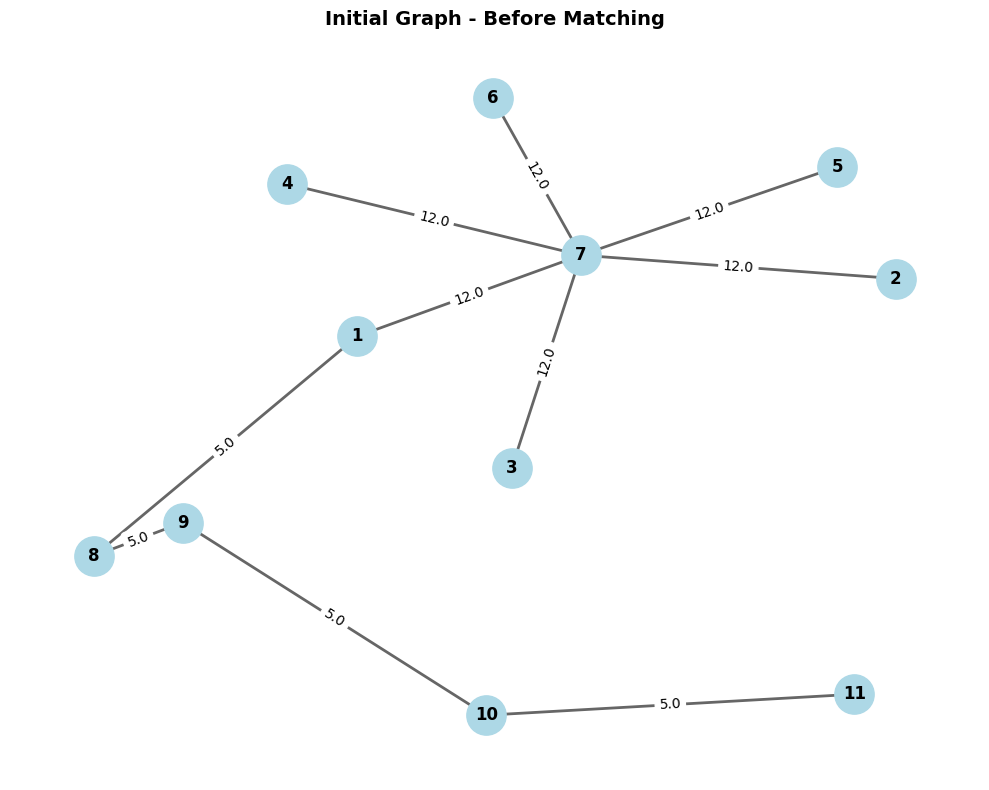

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create NetworkX graph for visualization
G = graph._graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)

# Draw edges with weights
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax)
edge_labels = {(u, v): f"{w:.1f}" for u, v, w in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10, ax=ax)

ax.set_title("Initial Graph - Before Matching", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Run Luby-Style Randomized Matching Algorithm

In [4]:
# Create algorithm instance with tunable activation probability
algo = LubyRandomizedMatching(seed=42, activation_probability=0.5)

# Create simulation configuration
config = SimulationConfig(
    max_rounds=100,
    collect_snapshots=True,
    random_seed=42
)

# Run scheduler
scheduler = Scheduler(graph, algo, config)
rounds = scheduler.run_until_termination()

print(f"Algorithm converged in {rounds} rounds")
print(f"Termination reason: {scheduler._termination_reason}")
print(f"Activation probability: 0.5")

Algorithm converged in 100 rounds
Termination reason: max_rounds_exceeded
Activation probability: 0.5


## 4. Extract and Validate Matching

In [5]:
# Extract matching
matching = algo.extract_matching(scheduler.state_store, graph)

# Validate matching
is_valid, error_msg = algo.validate_matching(matching, graph)
print(f"Valid matching: {is_valid}")
if not is_valid:
    print(f"Error: {error_msg}")

# Check if maximal
is_maximal = algo.is_maximal_matching(matching, graph)
print(f"Is maximal: {is_maximal}")

# Calculate total weight
total_weight = sum(
    graph.get_edge_weight(u, v)
    for u, v in matching.items() if u < v
)
print(f"\nMatching pairs: {len(matching) // 2}")
print(f"Total weight: {total_weight:.2f}")
print(f"\nMatching: {matching}")

Valid matching: True
Is maximal: True

Matching pairs: 3
Total weight: 22.00

Matching: {1: 8, 4: 7, 7: 4, 8: 1, 9: 10, 10: 9}


## 5. Visualize Matched Graph

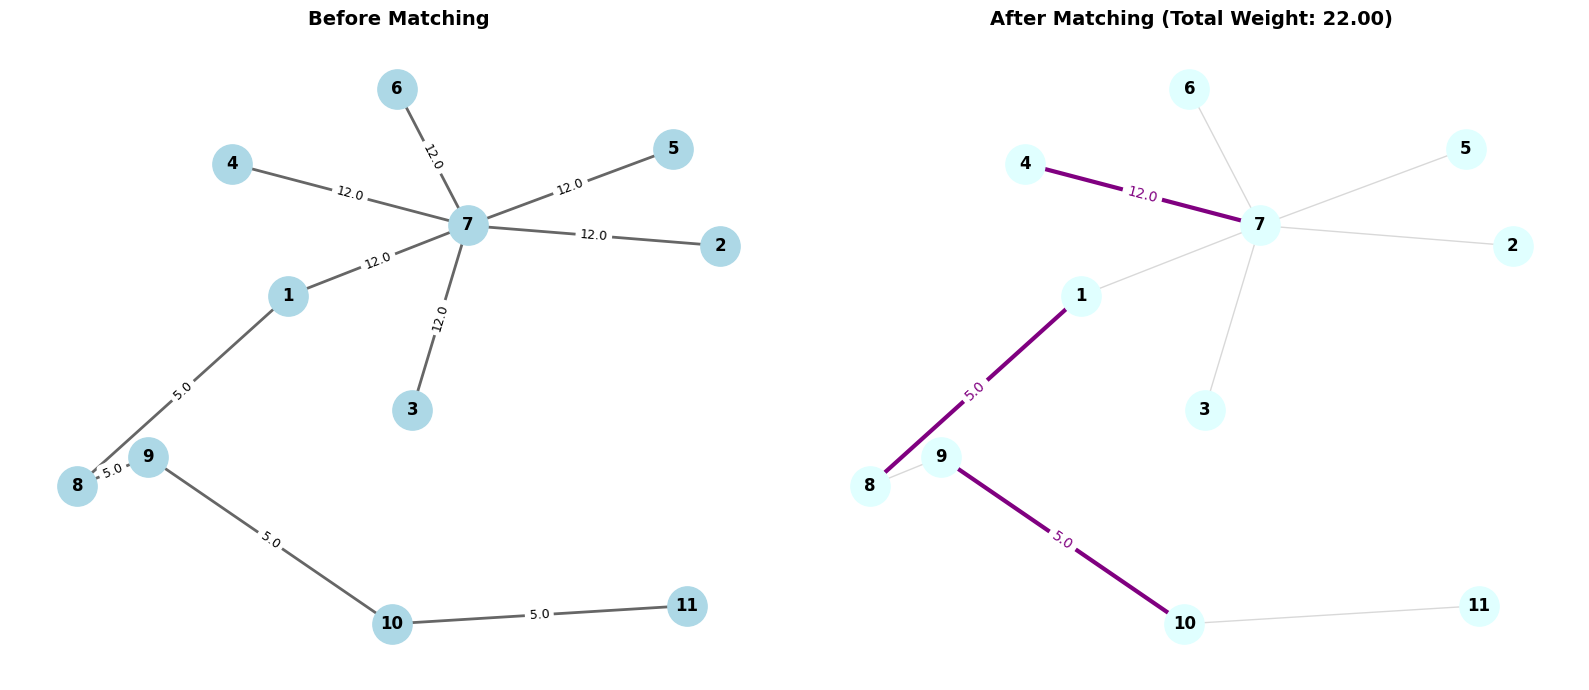

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Use the same layout for both graphs
G = graph._graph
pos = nx.spring_layout(G, seed=42, k=2, iterations=50)

# LEFT: Before matching
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=800, ax=ax1)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax1)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, ax=ax1)
edge_labels = {(u, v): f"{w:.1f}" for u, v, w in G.edges(data='weight')}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=9, ax=ax1)
ax1.set_title("Before Matching", fontsize=14, fontweight='bold')
ax1.axis('off')

# RIGHT: After matching
nx.draw_networkx_nodes(G, pos, node_color='lightcyan', node_size=800, ax=ax2)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax2)

# Draw all edges in light gray
nx.draw_networkx_edges(G, pos, width=1, alpha=0.3, edge_color='gray', ax=ax2)

# Highlight matched edges in purple
matched_edges = [(u, v) for u, v in matching.items() if u < v]
nx.draw_networkx_edges(G, pos, edgelist=matched_edges, width=3, edge_color='purple', ax=ax2)

# Draw edge labels only for matched edges
matched_labels = {(u, v): f"{graph.get_edge_weight(u, v):.1f}" for u, v in matched_edges}
nx.draw_networkx_edge_labels(G, pos, matched_labels, font_size=10, font_color='purple', ax=ax2)

ax2.set_title(f"After Matching (Total Weight: {total_weight:.2f})", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

## 6. Algorithm Statistics

In [7]:
# Collect metrics
metrics = scheduler.metrics.get_all_metrics()

print("\n=== Algorithm Statistics ===")
print(f"Convergence Rounds: {rounds}")
print(f"Final Matched Pairs: {len(matching) // 2}")
print(f"Total Weight: {total_weight:.2f}")

# Calculate metrics summary
total_messages_sent = sum(m.messages_sent for m in metrics)
total_messages_received = sum(m.messages_received for m in metrics)
print(f"Total Messages Sent: {total_messages_sent}")
print(f"Total Messages Received: {total_messages_received}")
print(f"\nFinal Metrics:")
final_metric = metrics[-1]
print(f"  Active Nodes: {final_metric.active_nodes}")
print(f"  Matched Nodes: {final_metric.matched_nodes}")
print(f"  Dormant Nodes: {final_metric.dormant_nodes}")


=== Algorithm Statistics ===
Convergence Rounds: 100
Final Matched Pairs: 3
Total Weight: 22.00
Total Messages Sent: 3096
Total Messages Received: 0

Final Metrics:
  Active Nodes: 0
  Matched Nodes: 0
  Dormant Nodes: 0


## 7. Convergence Visualization

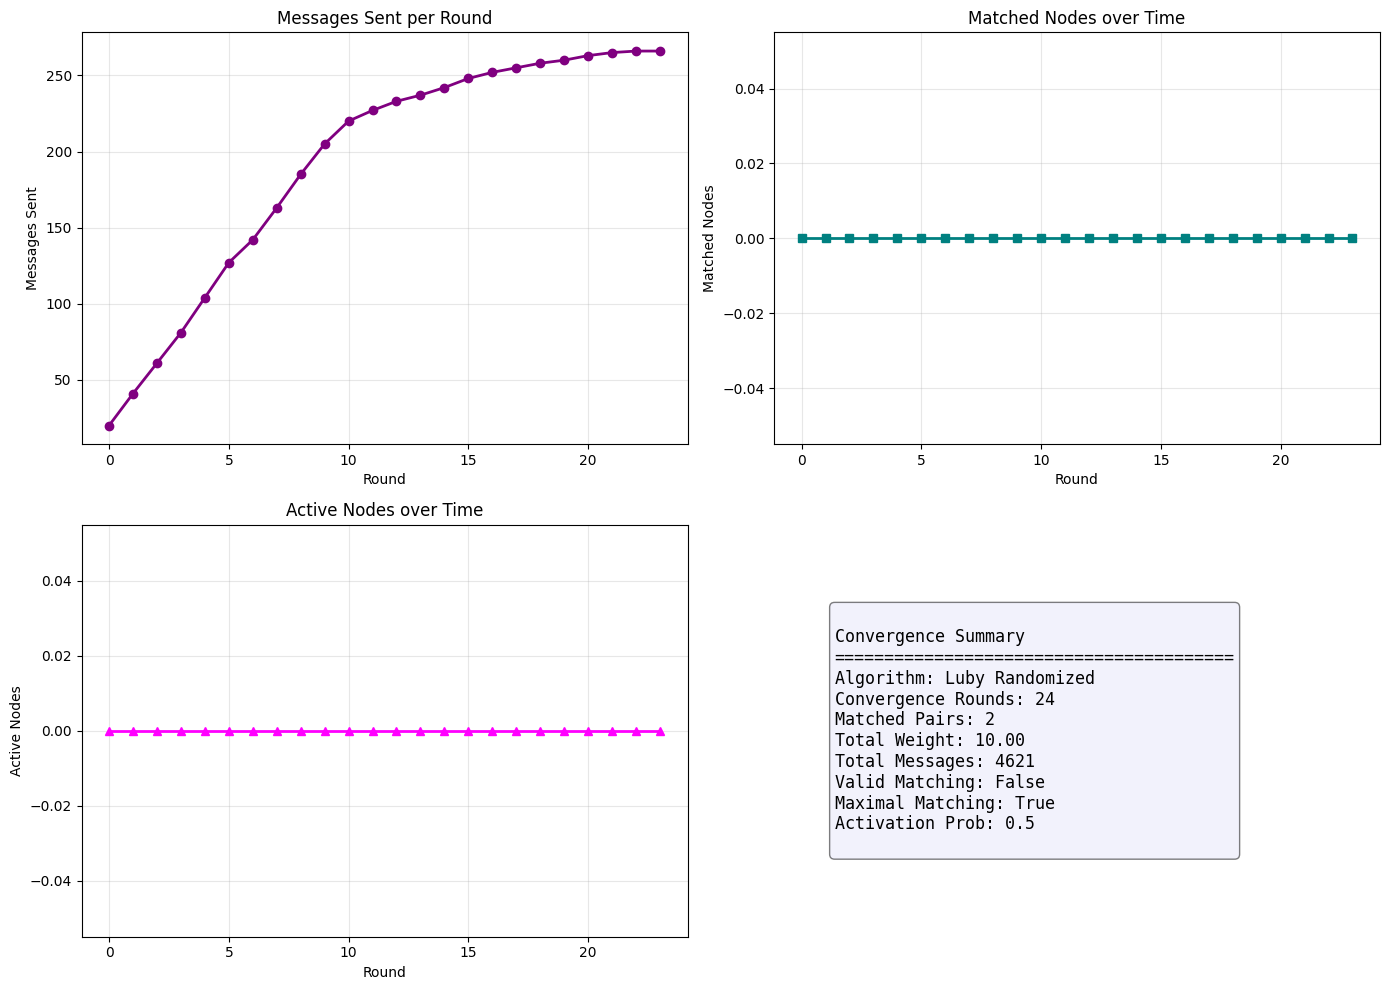

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

rounds_list = [m.round_num for m in metrics]
messages_sent = [m.messages_sent for m in metrics]
matched_nodes = [m.matched_nodes for m in metrics]
active_nodes = [m.active_nodes for m in metrics]

# Messages sent over time
axes[0, 0].plot(rounds_list, messages_sent, marker='o', linewidth=2, markersize=6, color='purple')
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Messages Sent')
axes[0, 0].set_title('Messages Sent per Round')
axes[0, 0].grid(True, alpha=0.3)

# Matched nodes over time
axes[0, 1].plot(rounds_list, matched_nodes, marker='s', linewidth=2, markersize=6, color='teal')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Matched Nodes')
axes[0, 1].set_title('Matched Nodes over Time')
axes[0, 1].grid(True, alpha=0.3)

# Active nodes over time
axes[1, 0].plot(rounds_list, active_nodes, marker='^', linewidth=2, markersize=6, color='magenta')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Active Nodes')
axes[1, 0].set_title('Active Nodes over Time')
axes[1, 0].grid(True, alpha=0.3)

# Convergence summary
axes[1, 1].axis('off')
summary_text = f"""
Convergence Summary
{'='*40}
Algorithm: Luby Randomized
Convergence Rounds: {rounds}
Matched Pairs: {len(matching) // 2}
Total Weight: {total_weight:.2f}
Total Messages: {total_messages_sent}
Valid Matching: {is_valid}
Maximal Matching: {is_maximal}
Activation Prob: 0.5
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.5))

plt.tight_layout()
plt.show()

## 8. Running Multiple Seeds for Probabilistic Analysis

In [15]:
# Since this is a randomized algorithm, let's run it multiple times with different seeds
import numpy as np

results = []
seeds = [42, 123, 456, 789, 999]

for seed in seeds:
    algo_run = LubyRandomizedMatching(seed=seed, activation_probability=0.5)
    config_run = SimulationConfig(
        max_rounds=100,
        collect_snapshots=False,
        random_seed=seed
    )
    scheduler_run = Scheduler(graph, algo_run, config_run)
    rounds_run = scheduler_run.run_until_termination()
    
    matching_run = algo_run.extract_matching(scheduler_run.state_store, graph)
    weight_run = sum(
        graph.get_edge_weight(u, v)
        for u, v in matching_run.items() if u < v
    )
    
    results.append({
        'seed': seed,
        'rounds': rounds_run,
        'matched_pairs': len(matching_run) // 2,
        'weight': weight_run
    })

print("\n=== Probabilistic Analysis (5 Runs) ===")
print(f"{'Seed':<8} {'Rounds':<10} {'Pairs':<10} {'Weight':<10}")
print("-" * 40)
for r in results:
    print(f"{r['seed']:<8} {r['rounds']:<10} {r['matched_pairs']:<10} {r['weight']:<10.2f}")

avg_rounds = np.mean([r['rounds'] for r in results])
avg_weight = np.mean([r['weight'] for r in results])
print("-" * 40)
print(f"{'AVG':<8} {avg_rounds:<10.1f} {'':<10} {avg_weight:<10.2f}")


=== Probabilistic Analysis (5 Runs) ===
Seed     Rounds     Pairs      Weight    
----------------------------------------
42       35         4          60.00     
123      13         4          60.00     
456      29         4          60.00     
789      33         4          60.00     
999      18         4          60.00     
----------------------------------------
AVG      25.6                  60.00     
